ds
1995-01-01    70.1
1995-02-01    66.0
1995-03-01    74.9
1995-04-01    67.1
1995-05-01    72.1
Freq: MS, Name: index, dtype: float64

1995-01-01 00:00:00 --- 2026-02-01 00:00:00 freq: MS


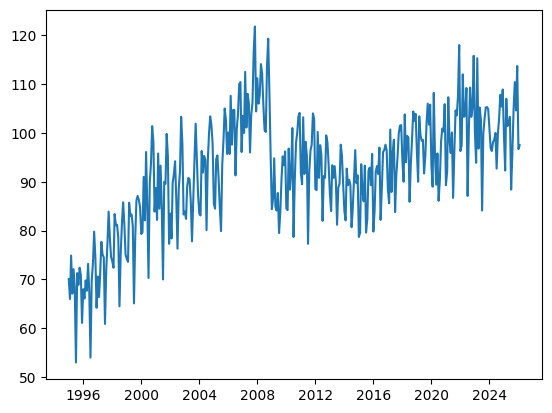

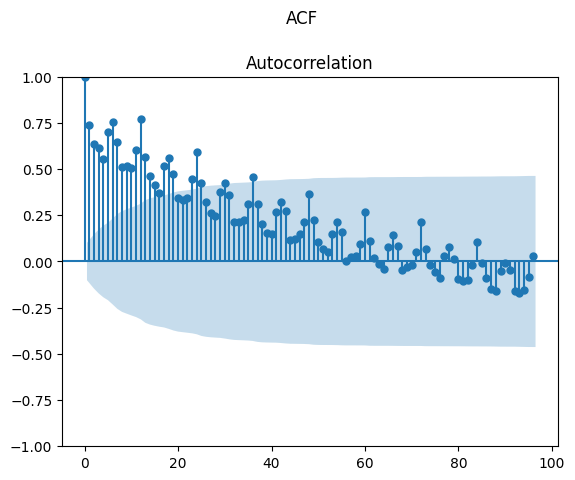

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

path = "/Users/lauriwikberg/Desktop/pr/index.csv"
df = pd.read_csv(path, sep=";")
df.columns = ["Year", "index"]

df["ds"] = df["Year"].str.replace("M", "-")
df["ds"] = pd.PeriodIndex(df["ds"], freq="M").to_timestamp()
df = df.set_index("ds")
df = df.asfreq("MS")
y = df["index"]

display(y.head())
print(y.index.min(), "---", y.index.max(), "freq:", y.index.freqstr)

plt.plot(y)

fig = plot_acf(y, lags=96)
fig.suptitle("ACF", y=1.02)
plt.show()


ADF Statistic: -5.998319630680743
p-value: 1.6807173813247738e-07
KPSS Statistic: 0.017190719537823633
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/var/folders/sn/g3frp9k17g79rg9szq7r6x1h0000gn/T/ipykernel_8308/2852834144.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit_values = kpss(y_diff_seasonal, regression='c', nlags="auto")


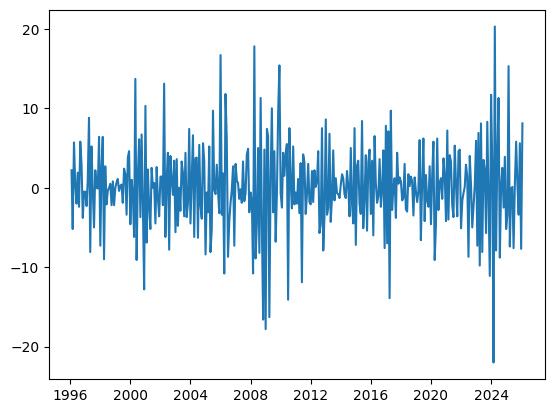

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

y_diff = y.diff().dropna()
y_diff_seasonal = y_diff.diff(12).dropna()

plt.plot(y_diff_seasonal)

result = adfuller(y_diff_seasonal)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

stat, p_value, lags, crit_values = kpss(y_diff_seasonal, regression='c', nlags="auto")

print(f"KPSS Statistic: {stat}")
print(f"p-value: {p_value}")
print(f"Critical Values: {crit_values}")

Train: 1995-01-01 --- 2019-11-01 n= 299
Test: 2019-12-01 --- 2026-02-01 n= 75


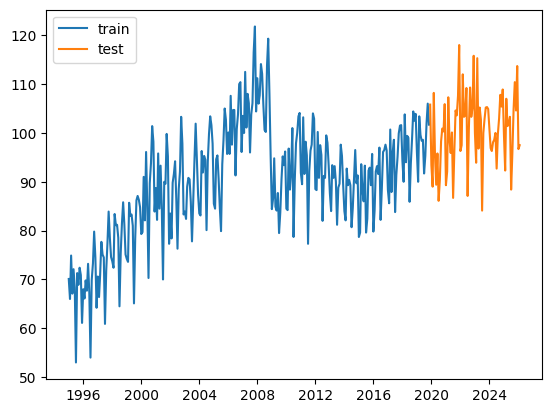

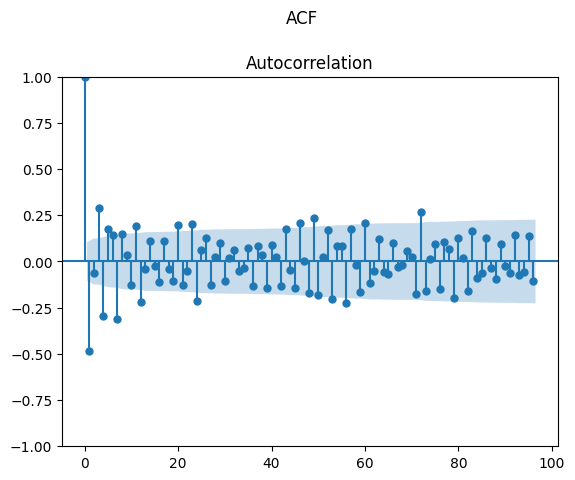

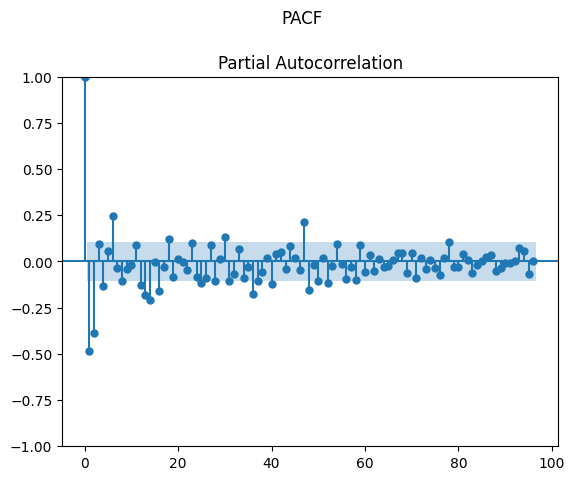

In [ ]:
h = 75
train = y.iloc[:-h]
test  = y.iloc[-h:]

print("Train:", train.index.min().date(), "---", train.index.max().date(), "n=", len(train))
print("Test:", test.index.min().date(),  "---", test.index.max().date(),  "n=", len(test))

plt.figure()
plt.plot(train, label="train")
plt.plot(test, label="test")
plt.legend()
plt.show()

fig = plot_acf(y_diff_seasonal, lags=96)
fig.suptitle("ACF", y=1.02)
plt.show()

fig = plot_pacf(y_diff_seasonal, lags=96, method="ywm")
fig.suptitle("PACF", y=1.02)
plt.show()

In [ ]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)
print(res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              index   No. Observations:                  299
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -765.749
Date:                            Wed, 29 Apr 2026   AIC                           1537.499
Time:                                    21:37:36   BIC                           1548.316
Sample:                                01-01-1995   HQIC                          1541.842
                                     - 11-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5974      0.038    -15.766      0.000      -0.672      -0.523
ma.S.L12      -0.7595      0.041   

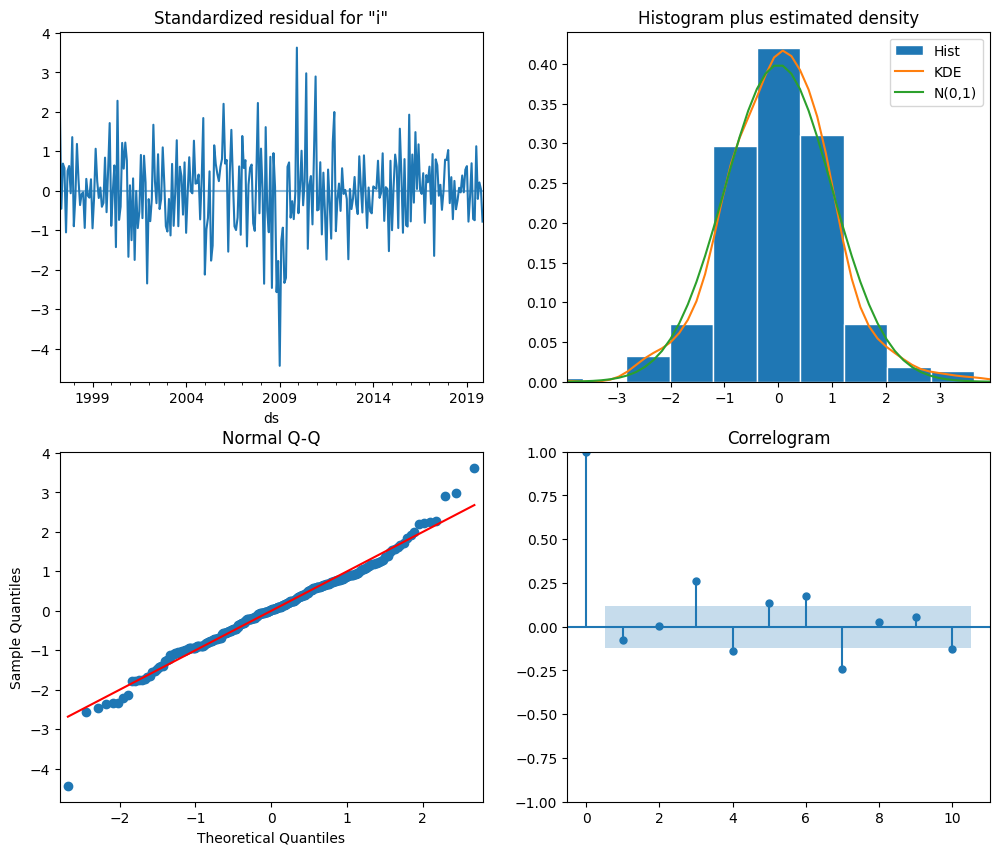

,lb_stat,lb_pvalue
12,19.25875,0.082472
24,31.54272,0.138743


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

res.plot_diagnostics(figsize=(12, 10))
plt.show()

lb = acorr_ljungbox(res.resid.dropna(), lags=[12, 24], return_df=True)
display(lb)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

fc = res.get_forecast(steps=h)

fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

fc_lower = fc_ci.iloc[:, 0]
fc_upper = fc_ci.iloc[:, 1]


mae = mean_absolute_error(test, fc_mean)
rmse = np.sqrt(mean_squared_error(test, fc_mean))
mape = np.mean(np.abs((test - fc_mean) / test)) * 100

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")


MAE : 3.825
RMSE: 4.660
MAPE: 3.84%


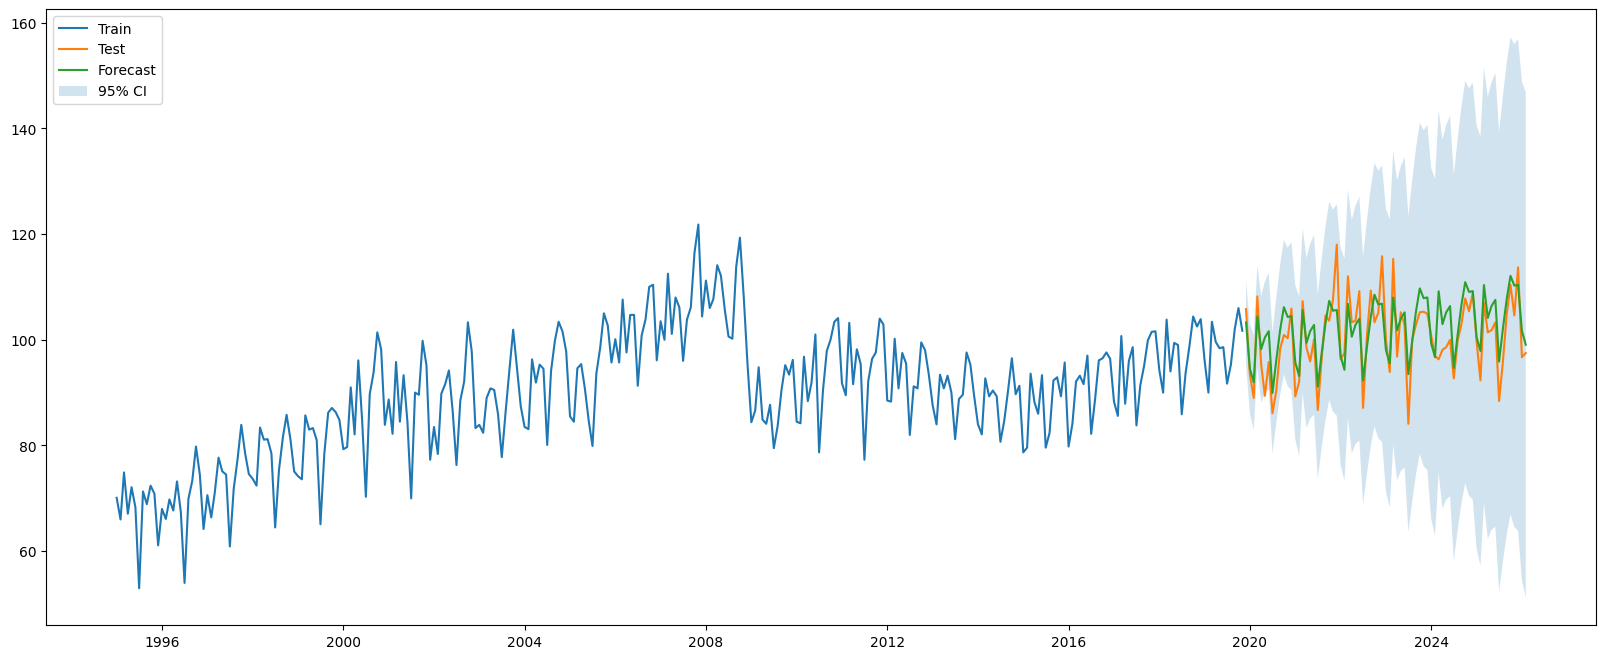

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(fc_mean, label="Forecast")
plt.fill_between(fc_mean.index, fc_lower, fc_upper, alpha=0.2, label="95% CI")
plt.legend()
plt.show()

,Unemployed,Vacancies
Q,,
2013-01-01,235,45300
2013-04-01,256,32500
2013-07-01,190,23500
2013-10-01,202,16600
2014-01-01,239,46000


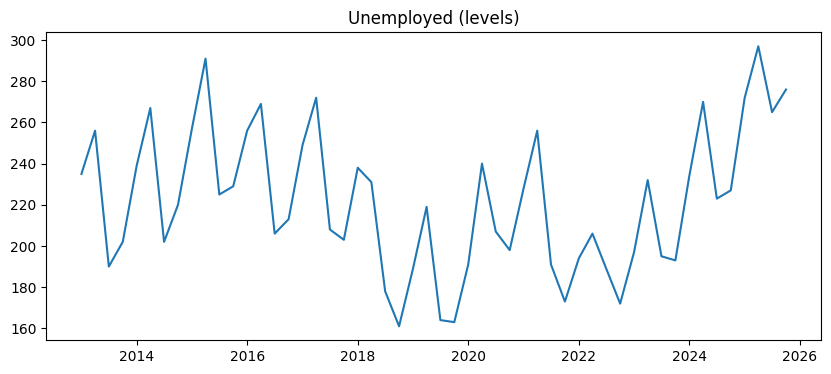

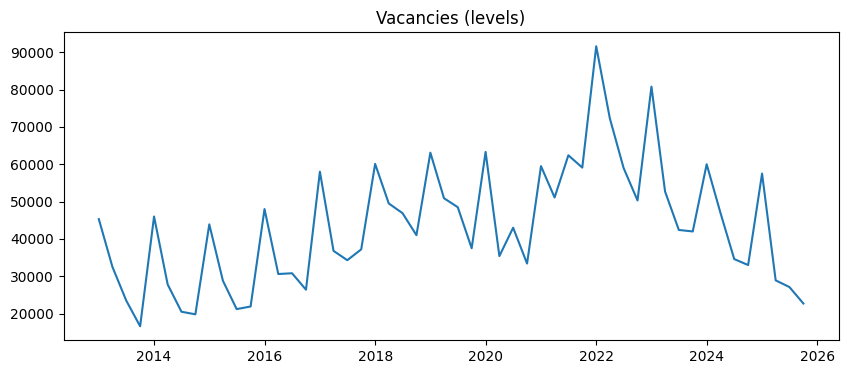

In [ ]:
import pandas as pd

path = "/Users/lauriwikberg/Desktop/pr/VAR.csv"
df = pd.read_csv(path, sep=";")

df.columns = ["Q", "Unemployed", "Vacancies"]

df["Q"] = pd.PeriodIndex(df["Q"], freq="Q").to_timestamp()

df = df.set_index("Q")
df = df.asfreq("QS")

data = df[["Unemployed", "Vacancies"]]

display(data.head())

plt.figure(figsize=(10,4))
plt.plot(data["Unemployed"])
plt.title("Unemployed (levels)")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(data["Vacancies"])
plt.title("Vacancies (levels)")
plt.show()

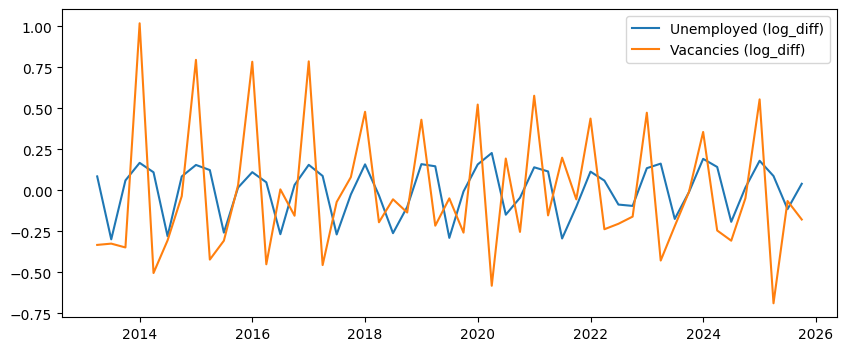

Unemployed
ADF Statistic: -1.6169294299658044
p-value: 0.4743394428422372
KPSS Statistic: 0.18692596021214386
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Vacancies
ADF Statistic: -2.7302468932563646
p-value: 0.06894888114597346
KPSS Statistic: 0.465593435378033
p-value: 0.04941589293287546
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/var/folders/sn/g3frp9k17g79rg9szq7r6x1h0000gn/T/ipykernel_8308/1486723748.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit_values = kpss(data_log_diff[col], regression='c', nlags="auto")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_log = np.log(data).dropna()
data_log_diff = data_log.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(data_log_diff["Unemployed"], label = "Unemployed (log_diff)")
plt.plot(data_log_diff["Vacancies"], label = "Vacancies (log_diff)")
plt.legend()
plt.show()

for col in data.columns:
    print(col)
    result = adfuller(data_log_diff[col])
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')

    stat, p_value, lags, crit_values = kpss(data_log_diff[col], regression='c', nlags="auto")

    print(f"KPSS Statistic: {stat}")
    print(f"p-value: {p_value}")
    print(f"Critical Values: {crit_values}")

In [ ]:
h_var = 7

train_var = data_log_diff.iloc[:-h_var]
test_var = data_log_diff.iloc[-h_var:]

print("Train:", train_var.index.min().date(), "---", train_var.index.max().date(), "n =", len(train_var))
print("Test:", test_var.index.min().date(),  "---", test_var.index.max().date(),  "n =", len(test_var))

Train: 2013-04-01 --- 2024-01-01 n = 44
Test: 2024-04-01 --- 2025-10-01 n = 7


In [ ]:
from statsmodels.tsa.api import VAR

model_var = VAR(train_var)
lag_sel = model_var.select_order(maxlags=4)

print(lag_sel.summary())

p = lag_sel.aic

print("Chosen lag p (bic): ", p)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -5.630      -5.546    0.003588      -5.600
1      -6.506      -6.253    0.001495      -6.414
2      -8.585      -8.162   0.0001874      -8.432
3      -8.884      -8.293   0.0001396      -8.670
4     -9.193*     -8.433*  0.0001033*     -8.918*
-------------------------------------------------
Chosen lag p (bic):  4


In [ ]:
var_res = model_var.fit(p)
print(var_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 29, Apr, 2026
Time:                     21:38:39
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -8.43307
Nobs:                     40.0000    HQIC:                  -8.91828
Log likelihood:           88.3463    FPE:                0.000103349
AIC:                     -9.19307    Det(Omega_mle):     6.88705e-05
--------------------------------------------------------------------
Results for equation Unemployed
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.011641         0.009735            1.196           0.232
L1.Unemployed        -0.224118         0.170392           -1.315           0.188
L1.Vacancies         -0.120538         0.064930        

,Unemployed,Vacancies
Q,,
2024-04-01,0.114695,-0.218777
2024-07-01,-0.182424,-0.153035
2024-10-01,-0.039217,0.045231
2025-01-01,0.148745,0.380933
2025-04-01,0.067454,-0.161547


Unemployed: MAE=0.042178, RMSE=0.048869
Vacancies: MAE=0.184578, RMSE=0.238876


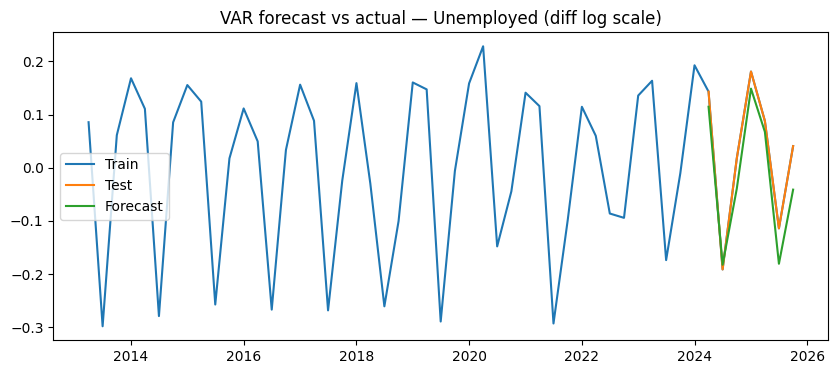

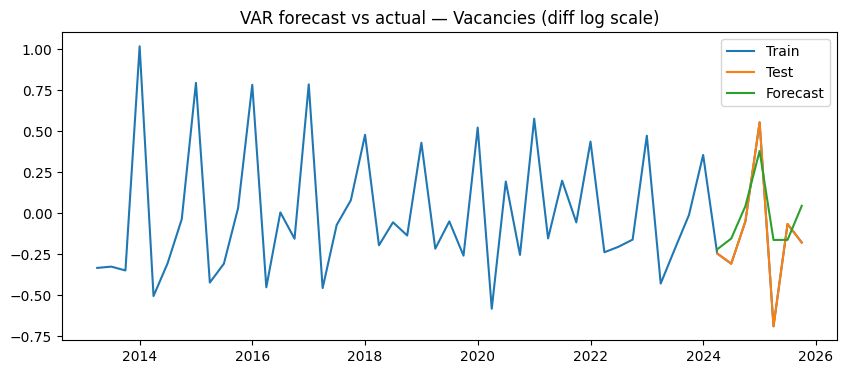

In [ ]:
fc_values_var = var_res.forecast(y=train_var.values[-p:], steps=h_var)
fc_var = pd.DataFrame(fc_values_var, index=test_var.index, columns=train_var.columns)

display(fc_var.head())
for col in test_var.columns:
    mae = mean_absolute_error(test_var[col], fc_var[col])
    rmse = np.sqrt(mean_squared_error(test_var[col], fc_var[col]))
    print(f"{col}: MAE={mae:.6f}, RMSE={rmse:.6f}")

for col in test_var.columns:
    plt.figure(figsize=(10,4))
    plt.plot(data_log_diff[col], label="Train")
    plt.plot(test_var[col], label="Test")
    plt.plot(fc_var[col], label="Forecast")
    plt.title(f"VAR forecast vs actual — {col} (diff log scale)")
    plt.legend()
    plt.show()

,Unemployed,Vacancies
Q,,
2024-04-01,262.438370,48210.033433
2024-07-01,218.676265,41369.011791
2024-10-01,210.266510,43283.147885
2025-01-01,243.988381,63351.354277
2025-04-01,261.014276,53901.013505


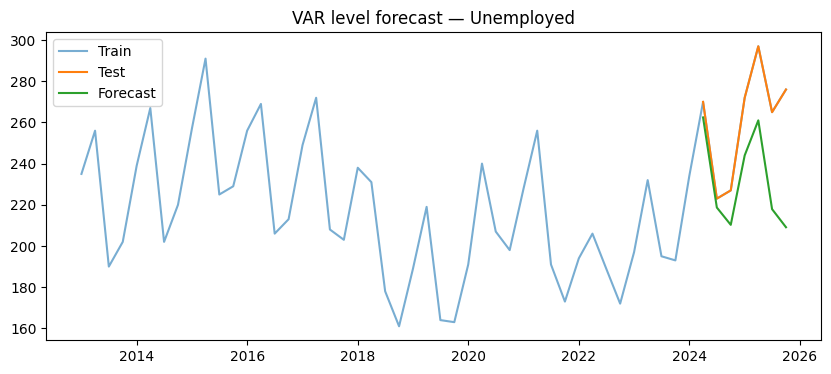

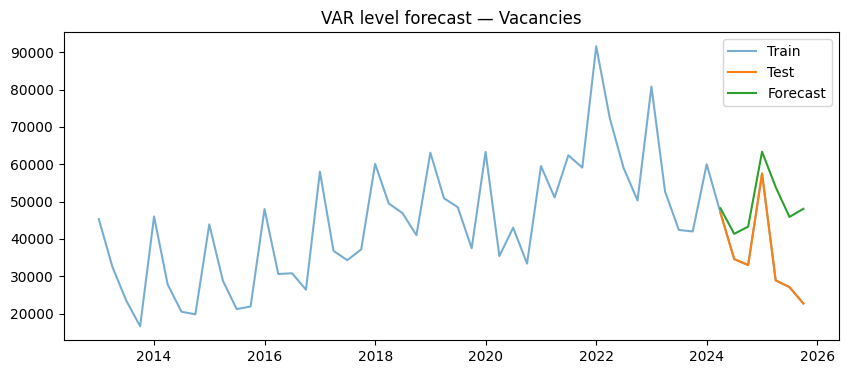

In [ ]:
last_log = data_log.iloc[-h_var-1] 

log_fc = fc_var.cumsum()
log_fc = log_fc.add(last_log, axis=1)

level_fc = np.exp(log_fc)

level_actual = data.loc[level_fc.index]

display(level_fc.head())

for col in level_fc.columns:
    plt.figure(figsize=(10,4))

    plt.plot(data[col], label="Train", alpha=0.6)

    plt.plot(level_actual[col], label="Test")

    plt.plot(level_fc[col], label="Forecast")
    
    plt.title(f"VAR level forecast — {col}")
    plt.legend()
    plt.show()